# Exercise 4
**Cristina Correa - 1819211867**


Introduce a dropout layer, as follows:


In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from keras import layers, Model
from keras.callbacks import EarlyStopping

# Ensure TensorFlow backend
os.environ["KERAS_BACKEND"] = "tensorflow"

file_url = "http://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
dataframe = pd.read_csv(file_url)

dataframe.shape

# Here's a preview of a few samples:
dataframe.head()

# Let's split the data into a training and validation set:
val_dataframe = dataframe.sample(frac=0.2, random_state=1337)
train_dataframe = dataframe.drop(val_dataframe.index)
print(
    f"Using {len(train_dataframe)} samples for training "
    f"and {len(val_dataframe)} for validation"
)


# Convert dataframes to tf.data.Datasets
def dataframe_to_dataset(dataframe, target="target"):
    dataframe = dataframe.copy()
    labels = dataframe.pop(target)
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe)).batch(32)
    return ds


# Let's generate `tf.data.Dataset` objects for each dataframe:
train_ds = dataframe_to_dataset(train_dataframe)
val_ds = dataframe_to_dataset(val_dataframe)


# Preprocessing layers for numerical and categorical features
def encode_feature(feature, name, dataset, is_string=False):
    lookup_class = layers.StringLookup if is_string else layers.IntegerLookup
    lookup = lookup_class(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name]).map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    return lookup(feature)


def normalize_feature(feature, name, dataset):
    normalizer = layers.Normalization()
    feature_ds = dataset.map(lambda x, y: tf.expand_dims(x[name], -1))
    normalizer.adapt(feature_ds)
    return normalizer(feature)


inputs = {
    "age": layers.Input(name="age", shape=(1,), dtype="float32"),
    "sex": layers.Input(name="sex", shape=(1,), dtype="int64"),
    "cp": layers.Input(name="cp", shape=(1,), dtype="int64"),
    "trestbps": layers.Input(name="trestbps", shape=(1,), dtype="float32"),
    "chol": layers.Input(name="chol", shape=(1,), dtype="float32"),
    "fbs": layers.Input(name="fbs", shape=(1,), dtype="int64"),
    "restecg": layers.Input(name="restecg", shape=(1,), dtype="int64"),
    "thalach": layers.Input(name="thalach", shape=(1,), dtype="float32"),
    "exang": layers.Input(name="exang", shape=(1,), dtype="int64"),
    "oldpeak": layers.Input(name="oldpeak", shape=(1,), dtype="float32"),
    "slope": layers.Input(name="slope", shape=(1,), dtype="int64"),
    "ca": layers.Input(name="ca", shape=(1,), dtype="int64"),
    "thal": layers.Input(name="thal", shape=(1,), dtype="string"),
}

# Encoded features
encoded_features = [
    encode_feature(inputs["sex"], "sex", train_ds),
    encode_feature(inputs["cp"], "cp", train_ds),
    encode_feature(inputs["fbs"], "fbs", train_ds),
    encode_feature(inputs["restecg"], "restecg", train_ds),
    encode_feature(inputs["exang"], "exang", train_ds),
    encode_feature(inputs["ca"], "ca", train_ds),
    encode_feature(inputs["thal"], "thal", train_ds, is_string=True),
    normalize_feature(inputs["age"], "age", train_ds),
    normalize_feature(inputs["trestbps"], "trestbps", train_ds),
    normalize_feature(inputs["chol"], "chol", train_ds),
    normalize_feature(inputs["thalach"], "thalach", train_ds),
    normalize_feature(inputs["oldpeak"], "oldpeak", train_ds),
    normalize_feature(inputs["slope"], "slope", train_ds),
]

Using 242 samples for training and 61 for validation


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.7024 - loss: 0.6271 - val_accuracy: 0.7541 - val_loss: 0.5548
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7916 - loss: 0.5301 - val_accuracy: 0.7705 - val_loss: 0.5160
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7548 - loss: 0.5191 - val_accuracy: 0.7869 - val_loss: 0.4855
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7956 - loss: 0.4859 - val_accuracy: 0.7541 - val_loss: 0.4622
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7901 - loss: 0.4349 - val_accuracy: 0.7705 - val_loss: 0.4439
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8017 - loss: 0.4605 - val_accuracy: 0.7705 - val_loss: 0.4314
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8134 - loss: 0.4191 - val_accuracy: 0.7705 - val_loss: 0.4212
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8370 - loss: 0.4089 - val_accuracy: 0.7705 - val_loss: 0.4137
Epoch 9

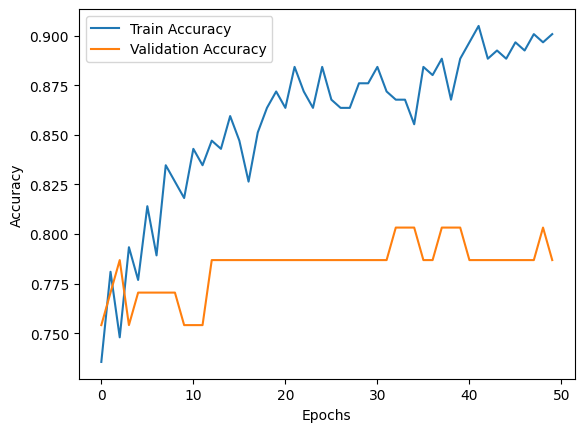

In [3]:
def build_model():
    all_features = layers.concatenate(encoded_features)
    x = layers.Dense(32, activation="relu")(all_features)
    x = layers.Dropout(0.3)(x)  # Dropout layer to reduce overfitting
    output = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs, output)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_model()

history = model.fit(train_ds, epochs=50, validation_data=val_ds)

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**Does it help reduce overfitting?**
- 

As our model doesn't have many parameters, we can't see a great change but adding a dropout layer helps with overfitting because thank's to that layer we are able to add randomly "drops" to a fraction of the neurons during training. This forces the model to rely on different paths each time it learns, preventing it from memorizing the training data too much